# Calibration of a line

Let us start with the smallest problem that still contains the whole workflow:
a straight line through twenty noisy points.  Everything the library asks of us
is here — we declare a model and what we believe about its parameters, we say
how the data are compared with it, we compile that into a problem, we hand the
problem to a sampler, and then we ask whether the answer is any good.

The [Bayesian recipe](https://en.wikipedia.org/wiki/Bayesian_inference) is the
same at every scale: a prior over parameters, a likelihood for the data, and a
posterior we explore with a sampler.  The only thing that grows in the later
notebooks is the error model.

Recipes: 1, 17

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx

plotstyle.use()

## Parameters and a model

A `Parameter` is a name with a
[prior](https://en.wikipedia.org/wiki/Prior_probability) (or finite bounds),
and a `Model` is a callable of the grid $x$ and the parameter values, in order,
carrying the parameters it consumes.

We deliberately choose a prior that disagrees with the data we are about to
generate: $m \sim \mathcal{N}(1, 1)$ while the truth is $m = 0.6$.  A prior
encodes what we think before we look, and it should be visible in the answer
when the data are few.

In [2]:
m = rx.Parameter("m", prior=stats.norm(1.0, 1.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(1.0, 1.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
line

Model(params=(m, b))

## Data

We draw twenty points from $y = m x + b$ with independent Gaussian noise of
known size $\sigma = 0.1$, which our imaginary experiment reports honestly as
`y_err`.  That honesty is the assumption every later notebook takes apart.

In [3]:
rng = np.random.default_rng(49)
truth = {"m": 0.6, "b": 2.0}
x = np.linspace(0.0, 1.0, 20)
y_true = truth["m"] * x + truth["b"]
sigma = 0.1
data = rx.Dataset(
    x, y_true + rng.normal(0.0, sigma, x.size), sigma * np.ones(x.size), label="toy"
)
data

Dataset('toy', n=20)

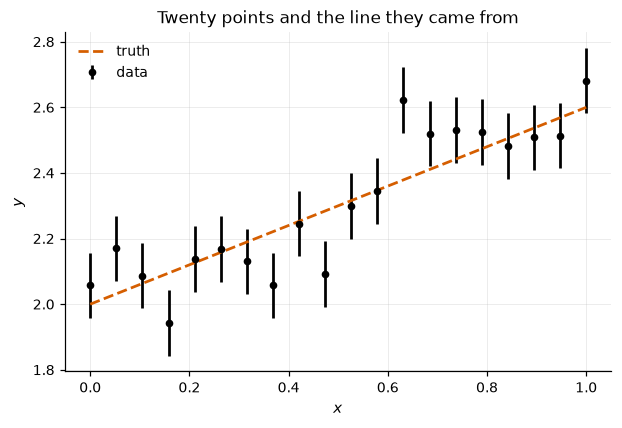

In [4]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.plot(x, y_true, "--", color=plotstyle.COLOURS[1], label="truth")
ax.set(xlabel="$x$", ylabel="$y$", title="Twenty points and the line they came from")
ax.legend()
plt.show()

## A comparison, a constraint and a problem

Three objects carry us from a declaration to something a sampler understands.

- A `Comparison` binds the model to this dataset's grid: it is the pairing of
  one model with one dataset.
- A `Constraint` is one likelihood over one or more comparisons.  By default
  its covariance is the diagonal of the reported errors, which is the
  "the experiment told us everything" assumption.
- `Problem` compiles the lot: it gives every parameter a column, assembles the
  prior, and exposes the densities a sampler needs.

Nothing is hidden in the compile step, and nothing user-facing is mutated by
it — we can compile the same declarations twice and get two independent
problems.

In [5]:
comp = rx.Comparison(data, line)
problem = rx.Problem([rx.Constraint([comp])])
print(problem)
print("columns:", problem.names)

Problem(ndim=2, constraints=1)
columns: ['m', 'b']


### What our prior alone predicts

Before the likelihood is involved at all, we can draw parameters from the prior
and push them through the model.  This is the
[prior predictive](https://en.wikipedia.org/wiki/Posterior_predictive_distribution#Prior_vs._posterior_predictive_distribution):
the data our prior thinks are plausible.  If it cannot produce anything like
the data we measured, we have learned something before fitting.

In [6]:
prior_draws = problem.sample_prior(200, rng=1)
x_fine = np.linspace(-0.5, 1.5, 60)
on_fine = line.bind(x_fine)  # the same model on a plotting grid
prior_curves = np.array(
    [on_fine(*s[problem.columns(line.params)]) for s in prior_draws]
)
prior_lo, prior_mid, prior_hi = rx.predictive.predictive_band(
    prior_curves, levels=(5, 50, 95)
)

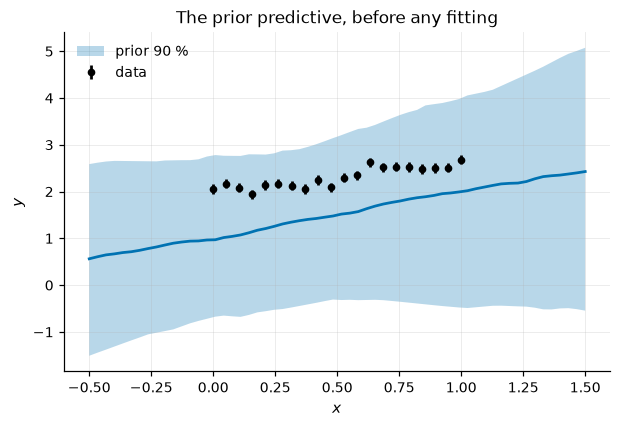

In [7]:
fig, ax = plt.subplots()
plotstyle.band(
    ax, x_fine, prior_lo, prior_hi, color=plotstyle.COLOURS[0], label="prior 90 %"
)
ax.plot(x_fine, prior_mid, color=plotstyle.COLOURS[0])
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.set(xlabel="$x$", ylabel="$y$", title="The prior predictive, before any fitting")
ax.legend()
plt.show()

### The likelihood is the $\chi^2$ we would have written by hand

With a diagonal covariance the Gaussian log-likelihood is $-\chi^2/2$ up to a
constant, where

$$\chi^2(\theta) = \sum_i \frac{(y_i - y_m(x_i; \theta))^2}{\sigma_i^2}.$$

`problem.chi2` is exactly that
[$\chi^2$](https://en.wikipedia.org/wiki/Goodness_of_fit#Regression_analysis),
so we can check it against the sum we would type out ourselves.  When the
covariance stops being diagonal — and it will, in every other notebook — this
becomes the [Mahalanobis
distance](https://en.wikipedia.org/wiki/Mahalanobis_distance), and the library
keeps computing it for us.

In [8]:
theta0 = np.array([1.0, 1.0])  # the prior mean
on_data = line.bind(x)
by_hand = np.sum(((data.y - on_data(*theta0)) / data.y_err) ** 2)
print(f"problem.chi2 = {problem.chi2(theta0):.3f}   by hand = {by_hand:.3f}")

problem.chi2 = 1343.608   by hand = 1343.608


## Running the calibration with emcee

The problem exposes everything a sampler wants and nothing it does not:
`log_posterior` is the density, `sample_prior` gives the walkers somewhere to
start, and `ndim` is the dimension.  We use
[emcee](https://emcee.readthedocs.io/), the affine-invariant ensemble sampler
of [Goodman & Weare
(2010)](https://doi.org/10.2140/camcos.2010.5.65), described in
[Foreman-Mackey et al. (2013)](https://arxiv.org/abs/1202.3665), but nothing
here is specific to it — recipe 16 drives the same problem with dynesty.

The chain comes back in `problem.names` order, so we always look columns up by
name through `problem.columns`, never by position.

In [9]:
n_walkers, n_steps = 32, 3000
sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
sampler.random_state = np.random.RandomState(2).get_state()
sampler.run_mcmc(problem.sample_prior(n_walkers, rng=3), n_steps, progress=False)
samples = sampler.get_chain(discard=500, thin=5, flat=True)
print(
    f"{samples.shape[0]} posterior rows, "
    f"acceptance {sampler.acceptance_fraction.mean():.2f}"
)

16000 posterior rows, acceptance 0.71


In [10]:
for name, parameter in zip(problem.names, problem.params):
    col = samples[:, problem.columns(parameter)]
    print(f"{name} = {col.mean():.3f} +/- {col.std():.3f}   (truth {truth[name]})")

m = 0.642 +/- 0.073   (truth 0.6)
b = 1.984 +/- 0.043   (truth 2.0)


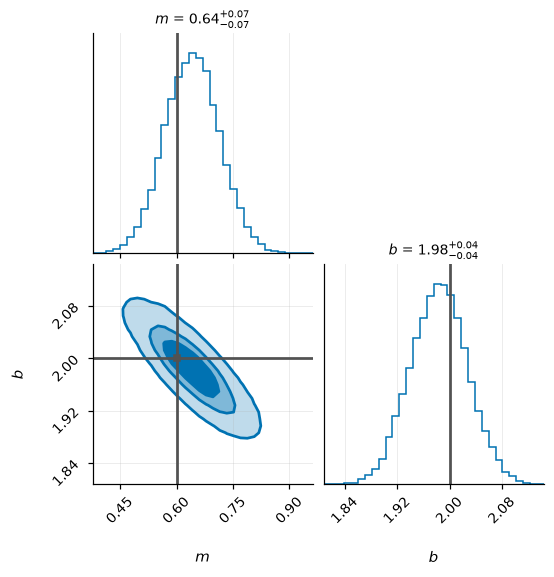

In [11]:
fig = corner.corner(
    samples,
    labels=[f"${p.latex}$" for p in problem.params],
    truths=[truth[n] for n in problem.names],
    **plotstyle.corner_kwargs(),
)
plt.show()

## The posterior predictive on any grid

The model is not tied to the grid we measured on: binding it to a finer, wider
grid gives us the prediction where we have no data, which is where a
calibration is usually asked to work.  The band below is the percentile
envelope of the line over posterior rows, and it fans out beyond the data,
as it should.

In [12]:
post_curves = np.array(
    [on_fine(*s[problem.columns(line.params)]) for s in samples[::20]]
)
post_lo, post_mid, post_hi = rx.predictive.predictive_band(
    post_curves, levels=(5, 50, 95)
)

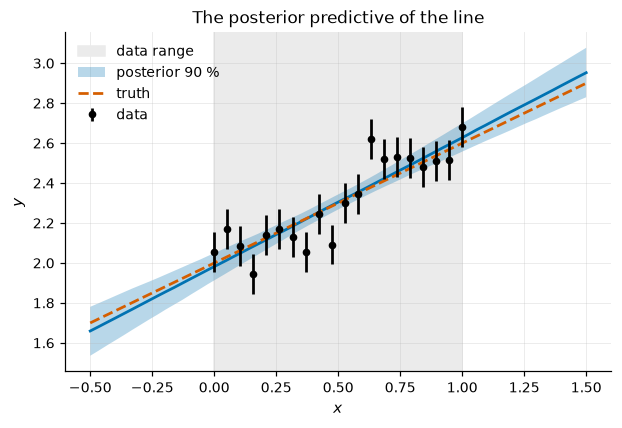

In [13]:
fig, ax = plt.subplots()
ax.axvspan(x.min(), x.max(), color="0.92", zorder=0, label="data range")
plotstyle.band(
    ax, x_fine, post_lo, post_hi, color=plotstyle.COLOURS[0], label="posterior 90 %"
)
ax.plot(x_fine, post_mid, color=plotstyle.COLOURS[0])
ax.plot(
    x_fine,
    truth["m"] * x_fine + truth["b"],
    "--",
    color=plotstyle.COLOURS[1],
    label="truth",
)
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.set(xlabel="$x$", ylabel="$y$", title="The posterior predictive of the line")
ax.legend()
plt.show()

## Is our error model calibrated?

The band above is the uncertainty of the *line*.  The posterior predictive of
the *data* adds the error model on top: draws of $y_m(\theta) + \text{noise}$
at the measured points.  That is the quantity we can actually check against
what we observed.

If the error model is right, a central 68 % interval of those draws should
contain about 68 % of the points, and likewise at every level — so the
empirical coverage should follow the diagonal.  Twenty points make a coarse
curve, but a systematic sag below the diagonal would mean we are claiming more
precision than we have.

In [14]:
draws = rx.diagnostics.predictive_draws(problem, samples[::10], n_rep=4, rng=4)
levels = np.linspace(0.1, 0.9, 9)
c = problem.constraints[0]
coverage = rx.diagnostics.coverage_curve(draws, c.y[c.active], levels)

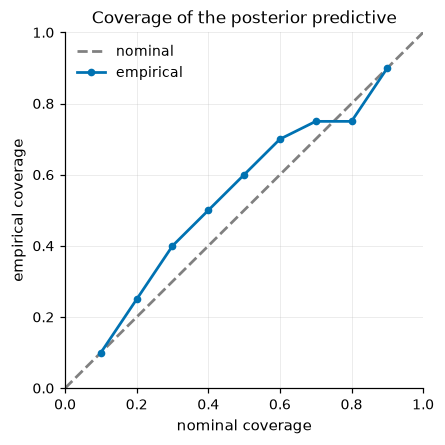

In [15]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
ax.plot(levels, coverage, "o-", color=plotstyle.COLOURS[0], label="empirical")
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    xlim=(0, 1),
    ylim=(0, 1),
    title="Coverage of the posterior predictive",
)
ax.legend()
plt.show()

In [16]:
width = rx.diagnostics.sharpness(draws).mean()
print(f"width of the 68 % predictive interval per point: {width:.3f}")

width of the 68 % predictive interval per point: 0.208


## Takeaways

- Declare, compile, sample.  The problem knows its columns, its prior and its
  densities; the sampler is whatever we like.
- Read chains by name through `problem.columns`, and bind the model to any grid
  when we want a prediction somewhere we did not measure.
- The posterior predictive check is the first question to ask of an error
  model, and here it passes because we built the data to satisfy it.

The next notebooks are about what to do when the reported errors are *not* the
whole story — which, with real measurements, is the usual case.